In [190]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

/Users/emmanuelfernandez/Documents/beluga-call-pipeline
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [191]:
import pandas as pd
from pathlib import Path

dir = "../new_results/optimization_last/mobile_net_8_layers"

# Loop through all folds and collect DataFrames
all_predictions = []
for fold_num in range(5):
    fold_path = Path(dir) / f"fold_{fold_num}" / "test_predictions.csv"
    fold_df = pd.read_csv(fold_path)
    all_predictions.append(fold_df)

# Merge all predictions into one DataFrame
test_predictions_df = pd.concat(all_predictions, ignore_index=True)
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold
0,BSM_20170724_11080200.pt,BSM,0.0,0.0,5.412258e-06,0.0,0.0,1.674104e-06,0.0,0.0,1.293481e-08,0.0,0.0,1.513410e-12,0
1,BSM_20170724_11370200.pt,BSM,0.0,0.0,1.823387e-07,0.0,0.0,9.426944e-08,0.0,0.0,1.319620e-07,0.0,0.0,1.709037e-05,0
2,BSM_20170724_12240300.pt,BSM,0.0,0.0,1.423269e-20,0.0,0.0,1.211738e-21,0.0,0.0,2.561401e-17,0.0,0.0,5.729794e-19,0
3,BSM_20170724_12560100.pt,BSM,0.0,0.0,3.554337e-09,0.0,0.0,1.798423e-11,0.0,0.0,5.802705e-10,0.0,0.0,7.999860e-11,0
4,BSM_20170724_12560300.pt,BSM,0.0,0.0,5.728493e-12,0.0,0.0,1.199267e-09,0.0,0.0,2.309838e-07,0.0,0.0,5.794316e-07,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17136,RDL_20220821_13385900.pt,RDL,0.0,0.0,1.778290e-09,0.0,0.0,6.859336e-09,0.0,0.0,1.035091e-10,0.0,0.0,7.028378e-13,4
17137,RDL_20220821_13390000.pt,RDL,0.0,0.0,1.528537e-07,0.0,0.0,3.090242e-09,0.0,0.0,2.750132e-10,0.0,0.0,1.623804e-12,4
17138,RDL_20220821_13390100.pt,RDL,0.0,0.0,1.051303e-06,0.0,0.0,1.018510e-06,0.0,0.0,1.199257e-07,0.0,0.0,2.643567e-09,4
17139,RDL_20220821_13390200.pt,RDL,0.0,0.0,4.754395e-07,0.0,0.0,1.768285e-07,0.0,0.0,8.428909e-09,0.0,0.0,5.589211e-08,4


In [192]:
# dir = "../new_results/sites_generalization_include_sample_last/leave_RDL_out_include_0"
# test_predictions_df = pd.read_csv(dir + "/test_predictions.csv")
# test_predictions_df = pd.read_csv(dir + "/Boat_1.0_test_predictions.csv")

In [193]:
import pandas as pd
labels_df = pd.read_csv("../../data/Verified_Dataset/labels/labels_merged.csv")
labels_df["ClipFilenamePt"] = labels_df["clip_filename"].str.replace(".wav", ".pt", regex=False)

merged_df = test_predictions_df.merge(
    labels_df[["ClipFilenamePt", "Boat", "HydrophoneSensitivity", "labeling_effort", "original_filename", "labeled_snippet_filename", "Begin Time (s)"]],
    how="left",
    left_on="Filename",
    right_on="ClipFilenamePt"
)
test_predictions_df = merged_df.drop(columns=["ClipFilenamePt"])


/var/folders/j5/prvccmy93sn3187zg4qcc1_40000gn/T/ipykernel_50986/2913277577.py:2: DtypeWarning: Columns (0: boat_labeling_file) have mixed types. Specify dtype option on import or set low_memory=False.
  labels_df = pd.read_csv("../../data/Verified_Dataset/labels/labels_merged.csv")


In [194]:
test_predictions_df["AnyCall_pred"] = test_predictions_df[["ECHO_pred", "HFPC_pred", "BBPC_pred", "Whistle_pred"]].any(axis=1)
test_predictions_df["AnyCall_true"] = test_predictions_df[["ECHO_true", "HFPC_true", "BBPC_true", "Whistle_true"]].any(axis=1)



In [195]:
pd.set_option('display.max_columns', None)
test_predictions_df.head(2)

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true
0,BSM_20170724_11080200.pt,BSM,0.0,0.0,5.412258e-06,0.0,0.0,1.674104e-06,0.0,0.0,1.293481e-08,0.0,0.0,1.513410e-12,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
1,BSM_20170724_11370200.pt,BSM,0.0,0.0,1.823387e-07,0.0,0.0,9.426944e-08,0.0,0.0,1.319620e-07,0.0,0.0,1.709037e-05,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False


In [196]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# Configuration
# =============================================================================



# =============================================================================
# Core Metrics Functions
# =============================================================================
def get_multilabel_metrics(df, call_types, true_suffix="_true", pred_suffix="_pred"):
    """
    Get multilabel metrics and confusion matrices for a dataframe subset.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing predictions and ground truth
    call_types : list
        List of call type names
    subset_name : str
        Name for this subset (e.g., "Overall", "KAM_2020", "boat_passage")
        
    Returns:
    --------
    dict
        Dictionary containing metrics, confusion matrices, and metadata
    """
    if len(df) == 0:
        return None
        
    y_true = df[[f"{c}{true_suffix}" for c in call_types]].astype(int).values
    y_pred = df[[f"{c}{pred_suffix}" for c in call_types]].astype(int).values
    
    # Get classification report
    report = classification_report(
        y_true, 
        y_pred, 
        target_names=call_types, 
        output_dict=True, 
        zero_division=0
    )
    
    # Get confusion matrices
    mcm_array = multilabel_confusion_matrix(y_true, y_pred)
    mcm = {call_type: mcm_array[i] for i, call_type in enumerate(call_types)}
    # Calculate false alarm rate for each class
    # mcm shape: (n_classes, 2, 2) where each 2x2 matrix is [[TN, FP], [FN, TP]]
    false_alarm_rates = {}
    for call_type in call_types:
        tn, fp = mcm[call_type][0, 0], mcm[call_type][0, 1]
        # False Alarm Rate = FP / (FP + TN), avoid division by zero
        far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        report[call_type]["false_alarm_rate"] = far
    
    return {
        'report': report,
        'mcm': mcm,
        'false_alarm_rates': false_alarm_rates,
        'y_true': y_true,
        'y_pred': y_pred,
        'n_samples': len(df)
    }


def compute_metrics_by_grouping(df, call_types, group_by=None):
    """
    Compute metrics for overall data and by grouping variable.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing predictions and ground truth
    call_types : list
        List of call type names
    group_by : str or None
        Column name to group by (e.g., 'context', 'site', or None for overall only)
        
    Returns:
    --------
    tuple
        (metrics_overall, metrics_by_group) where metrics_by_group is a dict
    """
    # Overall metrics
    metrics_overall = get_multilabel_metrics(df, call_types)
    metrics_overall["name"] = "Overall"
    
    # Group-specific metrics
    metrics_by_group = {}
    if group_by and group_by in df.columns:
        unique_groups = df[group_by].unique()
        for group in unique_groups:
            df_group = df[df[group_by] == group]
            if len(df_group) > 0:
                metrics_by_group[group] = get_multilabel_metrics(df_group, call_types)
                metrics_by_group[group]["name"] = str(group)
    
    
    return metrics_overall, metrics_by_group


def create_summary_dataframe(metrics_overall, metrics_by_group, call_types, group_name="Group"):
    """
    Create a summary dataframe from computed metrics.
    
    Parameters:
    -----------
    metrics_overall : dict
        Overall metrics dictionary
    metrics_by_group : dict
        Dictionary of metrics by group
    call_types : list
        List of call type names
    group_name : str
        Name for the grouping column (e.g., "Context", "Site")
        
    Returns:
    --------
    pd.DataFrame
        Summary dataframe with metrics for all call types and groups
    """
    summary_data = []
    
    for call in call_types:
        # Overall
        if metrics_overall:
            summary_data.append({
                'Call Type': call,
                group_name: 'Overall',
                'Precision': metrics_overall['report'][call]['precision'],
                'Recall': metrics_overall['report'][call]['recall'],
                'F1-Score': metrics_overall['report'][call]['f1-score'],
                'False Alarm Rate': metrics_overall['report'][call]['false_alarm_rate'],
                'Support': int(metrics_overall['report'][call]['support'])
            })
        
        # By group
        for group_key, metrics in metrics_by_group.items():
            if metrics:
                summary_data.append({
                    'Call Type': call,
                    group_name: group_key,
                    'Precision': metrics['report'][call]['precision'],
                    'Recall': metrics['report'][call]['recall'],
                    'F1-Score': metrics['report'][call]['f1-score'],
                    'False Alarm Rate': metrics['report'][call]['false_alarm_rate'],
                    'Support': int(metrics['report'][call]['support'])
                })
    
    return pd.DataFrame(summary_data)


def create_average_metrics_dataframe(metrics_overall, metrics_by_group, group_name="Group"):
    """
    Create dataframe with averaged metrics across all call types.
    
    Parameters:
    -----------
    metrics_overall : dict
        Overall metrics dictionary
    metrics_by_group : dict
        Dictionary of metrics by group
    group_name : str
        Name for the grouping column
        
    Returns:
    --------
    pd.DataFrame
        Dataframe with macro/micro/samples averages
    """
    avg_metrics = []
    
    # Overall
    if metrics_overall:
        report = metrics_overall['report']
        avg_metrics.append({
            group_name: 'Overall',
            'Macro Avg Precision': report['macro avg']['precision'],
            'Macro Avg Recall': report['macro avg']['recall'],
            'Macro Avg F1': report['macro avg']['f1-score'],
            'Micro Avg F1': report['micro avg']['f1-score'],
            'False Alarm Rate': metrics_overall['false_alarm_rates'],
            'Samples Avg F1': report['samples avg']['f1-score'],
            'n_samples': metrics_overall['n_samples']
        })
    
    # By group
    for group_key, metrics in metrics_by_group.items():
        if metrics:
            report = metrics['report']
            avg_metrics.append({
                group_name: group_key,
                'Macro Avg Precision': report['macro avg']['precision'],
                'Macro Avg Recall': report['macro avg']['recall'],
                'Macro Avg F1': report['macro avg']['f1-score'],
                'Micro Avg F1': report['micro avg']['f1-score'],
                'False Alarm Rate': metrics['false_alarm_rates'],
                'Samples Avg F1': report['samples avg']['f1-score'],
                'n_samples': metrics['n_samples']
            })
    
    return pd.DataFrame(avg_metrics)


def plot_metrics_comparison(summary_df, group_name="Group", exclude_overall=True, figsize=(14, 10)):
    """
    Create bar plots comparing metrics across call types and groups.
    
    Parameters:
    -----------
    summary_df : pd.DataFrame
        Summary dataframe with metrics
    group_name : str
        Name of the grouping column
    exclude_overall : bool
        Whether to exclude 'Overall' from visualization
    figsize : tuple
        Figure size
        
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure
    """
    # Filter data
    plot_df = summary_df.copy()
    if exclude_overall:
        plot_df = plot_df[plot_df[group_name] != 'Overall']
    
    if len(plot_df) == 0:
        print("No data to plot after filtering")
        return None
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'Support']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        # Pivot data for plotting
        pivot_data = plot_df.pivot(index='Call Type', columns=group_name, values=metric)
        
        pivot_data.plot(kind='bar', ax=ax, rot=0)
        ax.set_title(f'{metric} by Call Type and {group_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Call Type')
        ax.set_ylabel(metric)
        ax.legend(title=group_name, loc='best')
        ax.grid(axis='y', alpha=0.3)
        
        # Set y-limit only for percentage metrics
        if metric in ['Precision', 'Recall', 'F1-Score']:
            ax.set_ylim([0, 1.0])
    
    plt.tight_layout()
    return fig


def print_classification_report(metrics_overall, call_types):
    """Print formatted classification report."""
    if metrics_overall:
        print(f"\n{'='*80}")
        print("OVERALL CLASSIFICATION REPORT")
        print(f"{'='*80}\n")
        print(classification_report(
            metrics_overall['y_true'], 
            metrics_overall['y_pred'], 
            target_names=call_types, 
            zero_division=0
        ))


def print_summary_table(summary_df, group_name="Group"):
    """Print formatted summary table."""
    print(f"\n\n{'='*80}")
    print(f"SUMMARY TABLE: All Call Types by {group_name}")
    print(f"{'='*80}\n")
    print(summary_df.to_string(index=False))


def print_average_metrics(avg_df, group_name="Group"):
    """Print formatted average metrics table."""
    print(f"\n\n{'='*80}")
    print(f"AVERAGE METRICS ACROSS ALL CALL TYPES BY {group_name}")
    print(f"{'='*80}\n")
    print(avg_df.to_string(index=False))

In [197]:
test_predictions_df.groupby("Site")["AnyCall_true"].value_counts(dropna=False)

Site  AnyCall_true
BSM   False           7161
      True            1198
CAC   True            2159
      False           1608
KAM   True            2983
      False           1082
RDL   True             514
      False            436
Name: count, dtype: int64

In [198]:
test_predictions_df["Site"].value_counts(dropna=False)

Site
BSM    8359
KAM    4065
CAC    3767
RDL     950
Name: count, dtype: int64

In [199]:
# =============================================================================
# ANALYSIS BY CONTEXT
# =============================================================================
print("="*80)
print("ANALYSIS BY CONTEXT")
print("="*80)
# call_types = ["ECHO", "BBPC", "HFPC", "Whistle"] + ["AnyCall"]
call_types = ["ECHO", "BBPC", "HFPC", "Whistle"] 


test_predictions_df["Boat"] = test_predictions_df["Boat"].fillna(0)

test_predictions_df = test_predictions_df[test_predictions_df["Site"] == "RDL"]

# Compute metrics
metrics_overall, metrics_by_context = compute_metrics_by_grouping(
    test_predictions_df, call_types, group_by='Boat'
)
# metrics_overall, metrics_by_context = compute_metrics_by_grouping(
#     test_predictions_df, ["AnyCall"], group_by='labeled_snippet_filename'
# )
# Print reports
print_classification_report(metrics_overall, call_types)


ANALYSIS BY CONTEXT

OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.85      0.83      0.84       223
        BBPC       0.90      0.81      0.85       221
        HFPC       0.86      0.85      0.86       157
     Whistle       0.95      0.87      0.91       333

   micro avg       0.90      0.84      0.87       934
   macro avg       0.89      0.84      0.87       934
weighted avg       0.90      0.84      0.87       934
 samples avg       0.45      0.45      0.44       934



In [200]:
# # Get top 10 keys with the lowest report.Whistle.recall
# import numpy as np

# # Build a list of (key, recall) tuples, handling missing cases robustly
# key_recall = []
# for k, v in metrics_by_context.items():
#     try:
#         recall = v["report"]["Whistle"].get("recall", np.nan)
#         support = v["report"]["Whistle"].get("support", np.nan)
#     except Exception:
#         recall = np.nan
#     if support > 3:
#         key_recall.append((k, recall))

# # Sort by recall (ascending), NaNs to the end
# key_recall_sorted = sorted(key_recall, key=lambda x: (np.isnan(x[1]), x[1]))

# # Get top 10
# top10_lowest = key_recall_sorted[:10]

# print("Top 10 keys with lowest report.Whistle.recall:")
# for k, r in top10_lowest:
#     metrics_by_context[k]
#     print(k)
#     # print(metrics_by_context[k]["report"])
#     print_classification_report(metrics_by_context[k], call_types)

In [201]:

print_classification_report(metrics_by_context[0], call_types)
print_classification_report(metrics_by_context[1], call_types)
stop


OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.84      0.82      0.83       157
        BBPC       0.89      0.86      0.87       137
        HFPC       0.87      0.88      0.87       131
     Whistle       0.96      0.93      0.94       287

   micro avg       0.90      0.88      0.89       712
   macro avg       0.89      0.87      0.88       712
weighted avg       0.90      0.88      0.89       712
 samples avg       0.49      0.49      0.48       712


OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.88      0.86      0.87        66
        BBPC       0.94      0.73      0.82        84
        HFPC       0.83      0.73      0.78        26
     Whistle       0.88      0.50      0.64        46

   micro avg       0.89      0.72      0.80       222
   macro avg       0.88      0.71      0.78       222
weighted avg       0.90      0.72      0.79       222
 samples avg 

NameError: name 'stop' is not defined

In [ ]:
for call in call_types:
    print(f"{call}: {metrics_overall["report"][call]['false_alarm_rate'] * 100:.3f}%")
    print(metrics_overall["mcm"][call])


ECHO: 2.186%
[[11500   257]
 [  519  4865]]
BBPC: 0.734%
[[15964   118]
 [  237   822]]
HFPC: 0.918%
[[16185   150]
 [  147   659]]
Whistle: 1.987%
[[13912   282]
 [  435  2512]]
AnyCall: 2.187%
[[10062   225]
 [  436  6418]]


In [ ]:
test_predictions_df["Boat"].value_counts(dropna=False)

Boat
0.0    11163
1.0     5978
Name: count, dtype: int64

In [ ]:
for key, value in metrics_by_context.items():
    print()
    print(key, )
    print(test_predictions_df[test_predictions_df["Boat"] == key]["AnyCall_true"].value_counts(dropna=False))
    for call in call_types:

        print(f"{call}: {value["report"][call]['false_alarm_rate'] * 100:.3f}%")
        # print(value["mcm"][call])



0.0
AnyCall_true
False    7330
True     3833
Name: count, dtype: int64
ECHO: 1.488%
BBPC: 0.909%
HFPC: 0.661%
Whistle: 3.377%
AnyCall: 1.787%

1.0
AnyCall_true
True     2871
False    2801
Name: count, dtype: int64
ECHO: 4.749%
BBPC: 0.945%
HFPC: 0.550%
Whistle: 1.075%
AnyCall: 5.070%


In [ ]:
3600*0.03


108.0

In [ ]:
for fold_idx, fold_df in test_predictions_df.groupby("Fold"):
    print(fold_df["Boat"].value_counts(dropna=False))

Boat
0.0    2388
1.0     979
Name: count, dtype: int64
Boat
0.0    2016
1.0    1351
Name: count, dtype: int64
Boat
0.0    1948
1.0    1419
Name: count, dtype: int64
Boat
0.0    2421
1.0     946
Name: count, dtype: int64
Boat
0.0    2390
1.0     977
Name: count, dtype: int64


In [ ]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true
0,BSM_20170724_11080300.pt,BSM,0.0,0.0,5.232561e-09,0.0,0.0,3.602791e-09,0.0,0.0,1.564860e-11,0.0,0.0,6.546491e-15,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
1,BSM_20170724_11370200.pt,BSM,0.0,0.0,3.873535e-08,0.0,0.0,9.329182e-10,0.0,0.0,1.500955e-10,0.0,0.0,5.086012e-10,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
2,BSM_20170724_11370300.pt,BSM,0.0,0.0,3.557386e-11,0.0,0.0,1.807081e-11,0.0,0.0,8.282940e-09,0.0,0.0,1.503849e-06,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
3,BSM_20170724_12500300.pt,BSM,0.0,0.0,1.861418e-10,0.0,0.0,1.230424e-09,0.0,0.0,9.414891e-11,0.0,0.0,6.851429e-08,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
4,BSM_20170724_13132859.pt,BSM,0.0,0.0,6.516511e-05,0.0,0.0,2.212144e-08,0.0,0.0,3.324768e-04,0.0,1.0,9.999827e-01,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16830,RDL_20200901_19191674.pt,RDL,0.0,0.0,1.202951e-02,0.0,0.0,1.493103e-10,0.0,0.0,2.377552e-08,0.0,0.0,1.776518e-08,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200901190955.wav,NaN,NaN,False,False
16831,RDL_20200901_19192512.pt,RDL,0.0,0.0,9.348188e-04,0.0,0.0,7.628451e-12,0.0,0.0,2.214313e-09,0.0,0.0,8.463153e-10,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200901190955.wav,NaN,NaN,False,False
16832,RDL_20200906_14553196.pt,RDL,0.0,0.0,1.637192e-07,0.0,0.0,6.448618e-13,0.0,0.0,3.730531e-09,0.0,0.0,2.633798e-09,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200906144958.wav,NaN,NaN,False,False
16833,RDL_20200906_14553296.pt,RDL,0.0,0.0,5.529305e-11,0.0,0.0,1.831266e-14,0.0,0.0,4.258700e-10,0.0,0.0,1.828280e-09,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200906144958.wav,NaN,NaN,False,False


In [ ]:
test_predictions_df.groupby(["Fold", "Boat"])["BBPC_true"].value_counts(dropna=False)

Fold  Boat  BBPC_true
0     0.0   0.0          2176
            1.0           212
      1.0   0.0           954
            1.0            25
1     0.0   0.0          1865
            1.0           151
      1.0   0.0          1319
            1.0            32
2     0.0   0.0          1815
            1.0           133
      1.0   0.0          1358
            1.0            61
3     0.0   0.0          2244
            1.0           177
      1.0   0.0           919
            1.0            27
4     0.0   0.0          2245
            1.0           145
      1.0   0.0           955
            1.0            22
Name: count, dtype: int64

In [ ]:
metrics_by_context[0]["false_alarm_rates"]

{}



AVERAGE METRICS ACROSS ALL CALL TYPES BY Boat

   Boat  Macro Avg Precision  Macro Avg Recall  Macro Avg F1  Micro Avg F1 False Alarm Rate  Samples Avg F1  n_samples
Overall             0.900815          0.857241      0.878157      0.915882               {}        0.359881      17141
    0.0             0.913238          0.873899      0.892727      0.916814               {}        0.307902      11163
    1.0             0.854786          0.770836      0.807936      0.914422               {}        0.456943       5978


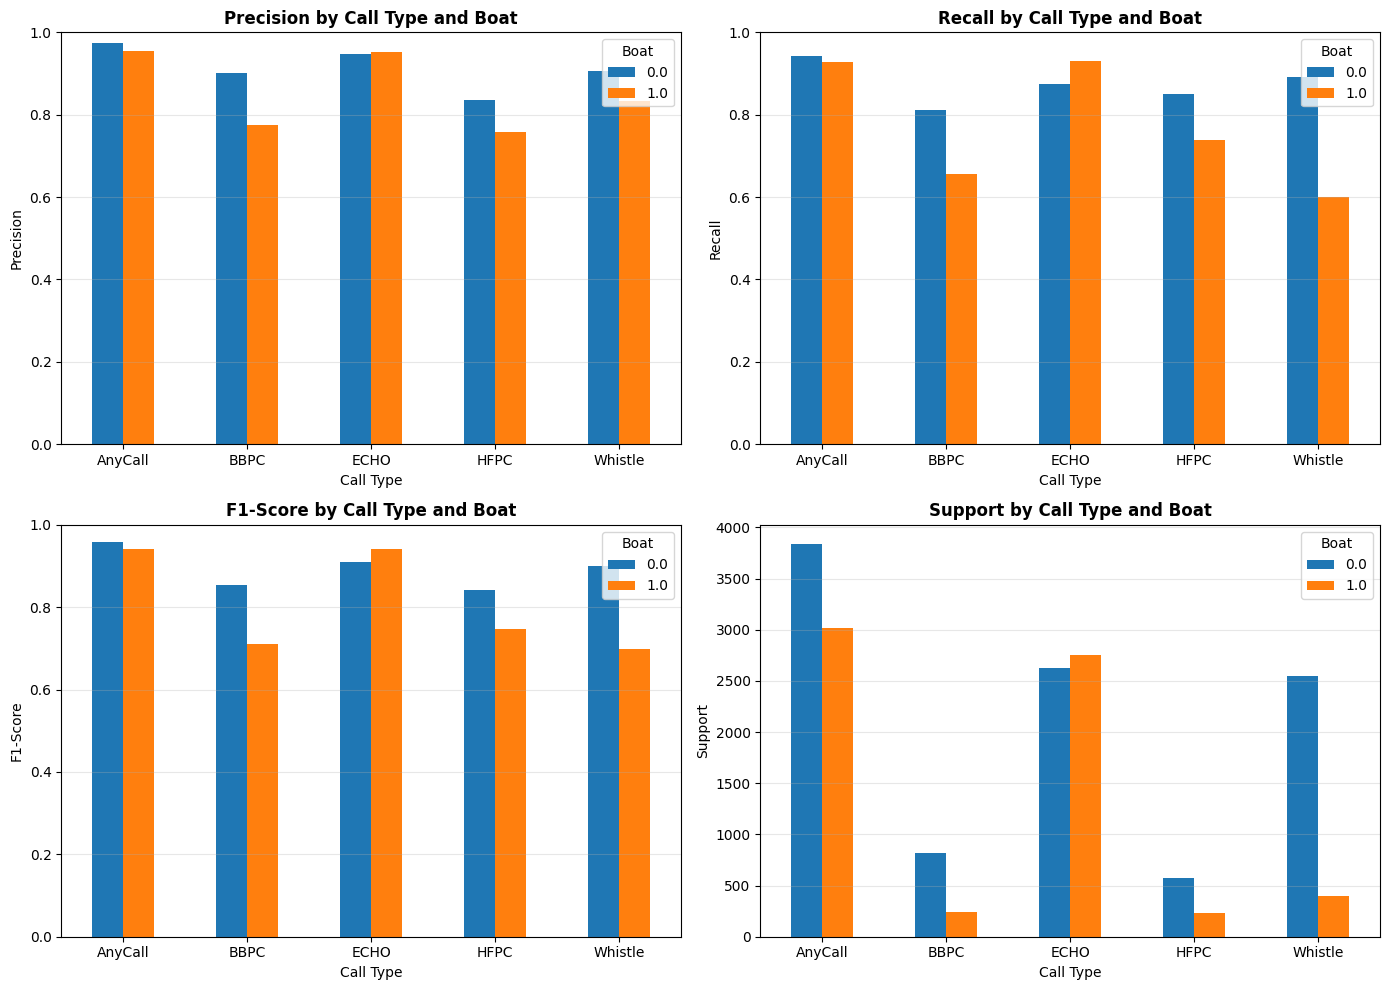

In [ ]:




avg_by_context = create_average_metrics_dataframe(
    metrics_overall, metrics_by_context, group_name="Boat"
)
print_average_metrics(avg_by_context, "Boat")


# Create summary dataframes
summary_by_context = create_summary_dataframe(
    metrics_overall, metrics_by_context, call_types, group_name="Boat"
)

# Plot
fig_context = plot_metrics_comparison(
    summary_by_context, group_name="Boat", exclude_overall=True
)
plt.show()

In [ ]:
avg_by_context

,Boat,Macro Avg Precision,Macro Avg Recall,Macro Avg F1,Micro Avg F1,False Alarm Rate,Samples Avg F1,n_samples
0,Overall,0.899173,0.867622,0.883041,0.915761,{},0.360274,16835
1,0.0,0.911242,0.886321,0.898344,0.918203,{},0.310928,11163
2,1.0,0.843624,0.774204,0.806195,0.911715,{},0.457392,5672


## False Alarm Rate

## looking at the errors spectrograms

In [ ]:
test_predictions_df["ECHO_correct"] = test_predictions_df["ECHO_pred"] == test_predictions_df["ECHO_true"]
test_predictions_df["BBPC_correct"] = test_predictions_df["BBPC_pred"] == test_predictions_df["BBPC_true"]
test_predictions_df["HFPC_correct"] = test_predictions_df["HFPC_pred"] == test_predictions_df["HFPC_true"]
test_predictions_df["Whistle_correct"] = test_predictions_df["Whistle_pred"] == test_predictions_df["Whistle_true"]
test_predictions_df["AnyCall_correct"] = test_predictions_df["AnyCall_pred"] == test_predictions_df["AnyCall_true"]

In [ ]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true,ECHO_correct,BBPC_correct,HFPC_correct,Whistle_correct,AnyCall_correct
0,BSM_20170724_11080200.pt,BSM,0.0,0.0,5.412258e-06,0.0,0.0,1.674104e-06,0.0,0.0,1.293481e-08,0.0,0.0,1.513410e-12,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
1,BSM_20170724_11370200.pt,BSM,0.0,0.0,1.823387e-07,0.0,0.0,9.426944e-08,0.0,0.0,1.319620e-07,0.0,0.0,1.709037e-05,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
2,BSM_20170724_12240300.pt,BSM,0.0,0.0,1.423269e-20,0.0,0.0,1.211738e-21,0.0,0.0,2.561401e-17,0.0,0.0,5.729794e-19,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
3,BSM_20170724_12560100.pt,BSM,0.0,0.0,3.554337e-09,0.0,0.0,1.798423e-11,0.0,0.0,5.802705e-10,0.0,0.0,7.999860e-11,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
4,BSM_20170724_12560300.pt,BSM,0.0,0.0,5.728493e-12,0.0,0.0,1.199267e-09,0.0,0.0,2.309838e-07,0.0,0.0,5.794316e-07,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17136,RDL_20220821_13385900.pt,RDL,0.0,0.0,1.778290e-09,0.0,0.0,6.859336e-09,0.0,0.0,1.035091e-10,0.0,0.0,7.028378e-13,4,1.0,-176.3,irene_rdl,6871.220821132704.wav,6871.220821133604.snippet.wav,175.0,False,False,True,True,True,True,True
17137,RDL_20220821_13390000.pt,RDL,0.0,0.0,1.528537e-07,0.0,0.0,3.090242e-09,0.0,0.0,2.750132e-10,0.0,0.0,1.623804e-12,4,1.0,-176.3,irene_rdl,6871.220821132704.wav,6871.220821133604.snippet.wav,176.0,False,False,True,True,True,True,True
17138,RDL_20220821_13390100.pt,RDL,0.0,0.0,1.051303e-06,0.0,0.0,1.018510e-06,0.0,0.0,1.199257e-07,0.0,0.0,2.643567e-09,4,1.0,-176.3,irene_rdl,6871.220821132704.wav,6871.220821133604.snippet.wav,177.0,False,False,True,True,True,True,True
17139,RDL_20220821_13390200.pt,RDL,0.0,0.0,4.754395e-07,0.0,0.0,1.768285e-07,0.0,0.0,8.428909e-09,0.0,0.0,5.589211e-08,4,1.0,-176.3,irene_rdl,6871.220821132704.wav,6871.220821133604.snippet.wav,178.0,False,False,True,True,True,True,True


In [ ]:
from data_preprocessing.spectrogram.spectrogram_generator import HYDROPHONE_SENSITIVITY, SpectrogramGenerator

spect_generator = SpectrogramGenerator(
        n_fft=2048,
        hop_length=int(2048/2),
        n_mels=64,
        fmin=200,
        sample_rate=192000, 
    )

In [ ]:
test_predictions_df["Boat"].value_counts()

Boat
0.0    11163
1.0     5978
Name: count, dtype: int64

In [ ]:
labels_df.columns

Index(['clip_filename', 'ECHO', 'BBPC', 'HFPC', 'Whistle', 'Call', 'Boat',
       'labeling_effort', 'DETAIL', 'Begin Time (s)', 'End Time (s)',
       'GROUNDTRUTH', 'Notes', 'original_filename', 'labeled_snippet_filename',
       'snippet_start_time', 'snippet_start_s', 'snippet_end_s', 'Site',
       'labeled_snippet_dir', 'HydrophoneModel', 'HydrophoneSensitivity',
       'clip_start_time', 'clip_end_time', 'DETAILS', 'boat_labeling_file',
       'boat_labeling_file_id', 'annotator', 'SnippetFilename', 'start_s',
       'end_s', 'FIXED_GROUNDTRUTH', 'ClipFilenamePt'],
      dtype='str')

In [ ]:
sample = test_predictions_df[(test_predictions_df["Boat"] == 0)& (test_predictions_df["ECHO_correct"] == False) & (test_predictions_df["ECHO_true"] == 0)]
sample


,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true,ECHO_correct,BBPC_correct,HFPC_correct,Whistle_correct,AnyCall_correct
358,BSM_20170729_15240329.pt,BSM,0.0,1.0,0.944276,0.0,1.0,9.915432e-01,1.0,1.0,9.601233e-01,1.0,1.0,9.997774e-01,0,0.0,-172.7,irene_5min,NaN,NaN,NaN,True,True,False,True,False,True,True
393,BSM_20170801_15481229.pt,BSM,0.0,1.0,0.959161,0.0,0.0,1.234622e-03,1.0,1.0,9.999726e-01,1.0,1.0,9.988505e-01,0,0.0,-172.7,irene_20min,NaN,NaN,NaN,True,True,False,True,True,True,True
404,BSM_20170801_17243270.pt,BSM,0.0,1.0,0.998218,1.0,0.0,2.401605e-02,0.0,0.0,1.087854e-03,1.0,1.0,9.999750e-01,0,0.0,-172.7,irene_20min,NaN,NaN,NaN,True,True,False,True,False,True,True
498,BSM_20170805_09540300.pt,BSM,0.0,1.0,0.580793,0.0,0.0,1.145517e-05,0.0,0.0,2.639211e-03,0.0,0.0,8.185685e-05,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,True,False,False,True,True,True,False
577,BSM_20170808_14093859.pt,BSM,0.0,1.0,0.927316,0.0,0.0,4.020601e-03,1.0,1.0,9.976180e-01,1.0,1.0,9.998883e-01,0,0.0,-172.7,irene_20min,NaN,NaN,NaN,True,True,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16851,RDL_20200725_09433400.pt,RDL,0.0,1.0,0.998612,0.0,0.0,3.987061e-05,1.0,0.0,4.974471e-01,1.0,1.0,9.999980e-01,4,0.0,-176.5,irene_20min,NaN,NaN,NaN,True,True,False,False,True,True,True
16852,RDL_20200725_09443600.pt,RDL,0.0,1.0,0.939798,0.0,0.0,4.178065e-06,1.0,1.0,9.999937e-01,1.0,1.0,9.998677e-01,4,0.0,-176.5,irene_20min,NaN,NaN,NaN,True,True,False,True,True,True,True
16887,RDL_20200730_08032583.pt,RDL,0.0,1.0,0.988036,0.0,0.0,9.576857e-08,0.0,0.0,4.201815e-11,0.0,0.0,2.745674e-12,4,0.0,-176.5,old_abs_from_3s_snippets,5675.200730080002.wav,NaN,NaN,True,False,False,True,True,True,False
16900,RDL_20200730_08500273.pt,RDL,0.0,1.0,0.970613,1.0,1.0,9.994012e-01,0.0,0.0,1.955047e-03,1.0,1.0,9.996402e-01,4,0.0,-176.5,irene_20min,NaN,NaN,NaN,True,True,False,True,True,True,True


In [ ]:

DATA_DIRECTORY = "../../data/"

wavs_folder = DATA_DIRECTORY + "Verified_Dataset/clip_wavs/"

# sample = labels_df[labels_df["Notes"].notna()]
# sample = labels_df[labels_df["clip_filename"] == "CAC_20210714_08342600.wav"]
# boat_df = test_predictions_df[test_predictions_df["Boat"] == 1]
# sample = boat_df[boat_df["Whistle_correct"] == False].sample(30)

# sample = test_predictions_df[(test_predictions_df["labeled_snippet_filename"] == "5725.200726191905.snippet.wav")& (test_predictions_df["Whistle"] == 1)].sample(10)
sample = test_predictions_df[(test_predictions_df["Boat"] == 0)& (test_predictions_df["ECHO_correct"] == False) & (test_predictions_df["ECHO_true"] == 0)]

# sample = test_predictions_df[test_predictions_df["Filename"] == "RDL_20200727_13012408.pt"]
count=0
for index, row in sample.iterrows():  
    print(f"{count}/{len(sample)}")
    count+=1
    print(row["Begin Time (s)"])
    wav_filename = row["Filename"].replace(".pt", ".wav")
    print(row["labeling_effort"])
    # print(row["anotator"])
    print(labels_df[labels_df["clip_filename"] ==wav_filename]["labeled_snippet_filename"])  
    
    title = f"{wav_filename}\n"

    for label in ["ECHO", "HFPC", "BBPC", "Whistle"]:
        true_val = row[f"{label}_true"] if f"{label}_true" in row else row.get(label, None)
        pred_val = row[f"{label}_pred"] if f"{label}_pred" in row else None
        title += f"{label}: true {int(true_val)} vs pred {int(pred_val)}   "
    title = title.strip()
    print(title)
    # print("Boat:", row["Boat"])

    file_path = wavs_folder + wav_filename

    audio, sr, original_sr = spect_generator.load_audio(file_path)


    power_spect = spect_generator.compute_mel_power_spect(audio)

    
    dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=row["HydrophoneSensitivity"])
  

    spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)

    # dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)
    
    # dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))

    